# CSE2530 Computational Intelligence
## Assignment 2: Ant Colony Optimization and Genetic Algorithms

|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6124607) |
| Student D  |        Miłosz Dudała (6212743) |

#### Imports

In [24]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time
import matplotlib.pyplot as plt

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

In [ ]:
random.seed(42)

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1: Look into the literature and explain how the TSP problem is usually defined.

The Travelling Salesman Problem (TSP) is usually defined as the problem that, given a collection of cities and the distances of travel between each pair of them, we need to find the shortest way of visiting all of the cities and returning to the starting point.

C. Dahiya and S. Sangwan, "Literature review on travelling salesman problem," International Journal of Research, 2018

#### Question 2: In a classic TSP, all cities (nodes) are singularly connected to all other nodes and relative distances are known and symmetric (aweighted complete graph). Give three ways in which our problem is different.

1. In our version, distances between nodes are not initially known and must first be calculated using the ACO algorithm.
2. We are working with a maze (a grid graph), not a complete graph, meaning nodes are not singularly connected but are connected through a sequence of accessible tiles. 
3. Given that ACO is a stochastic algorithm, it is likely that the found route from x to y might differ from one from y to x. 

#### Question 3: Why are computational intelligence techniques appropriate to solve the TSP? What are the characteristics which let us to tackle typically intractable problems?

TSP is an NP-hard problem with n! number of possible solutions for n cities. So far, the most optimal exact algorithms perform in O(n^2 * 2^n) time complexity which is extremely slow. Therefore, for larger applications, a heuristic algorithm is needed, and CI techniques provide such. 
The two most important characteristics allowing for tackling the problem are:
- Exploitation - we focus on the most promising results and discard those with poor results on the fitness function. This allows us to limit the search space from the initial n! possibilities.
- Exploration - genetic mutation allows us to escape local optima in search of the best solution.



### 1.2 Genetic Algorithm

In [ ]:
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    @param mutation_rate: the probability of mutation occurring in an offspring. Initialized to 0.01 by default. 
    """
    def __init__(self, generations, pop_size, mutation_rate=0.01):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate

    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        pop = self.initialize_population(self, len(tsp_data.product_locations))

    """
    Initializes the population with random chromosomes.
    @param num_products: the number of products to visit.
    @return a list of generated chromosomes.
    """
    def initialize_population(self, num_products):
        pass

    """
    Calculates the fitness score of a given chromosome.
    @param chromosome: the sequence of products.
    @param tsp_data: the data describing the problem distances.
    @return the computed fitness value.
    """
    def calculate_fitness(self, chromosome, tsp_data):
        pass

    """
    Selects parent chromosomes for reproduction based on fitness.
    @param population: the current generation of chromosomes.
    @param fitness_scores: the corresponding fitness values for the population.
    @return a tuple containing two selected parent chromosomes.
    """
    def select_parents(self, population, fitness_scores):
        pass

    """
    Performs crossover between two parent chromosomes to create a child.
    @param parent1: the first parent chromosome.
    @param parent2: the second parent chromosome.
    @return the generated child chromosome.
    """
    def crossover(self, parent1, parent2):
        pass

    """
    Applies random mutations to a chromosome.
    @param chromosome: the chromosome to mutate.
    @return the potentially mutated chromosome.
    """
    def mutate(self, chromosome):
        pass

#### Question 4: What do the genes represent? How will you encode your chromosomes?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 5: Which fitness function will you use? Why is this a suitable choice?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 6: How are parents selected from the population?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 7: What genetic operations did you implement? What are their functions (goals)?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 8: How do you prevent local minima?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 9: What is elitism? Have you applied it? Why (not)?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10: Apply your algorithm to find the shortest route using the provided data. What is the length of your solution? Is it optimal?

In [3]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 20
generations = 20
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

TypeError: 'NoneType' object is not subscriptable

<div style="background-color:#f1be3e">

_Put your code extra blocks above (if any) and write your answer here._

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11: What is the purpose of Ant Colony Optimisation? In what settings is it typically used?

The purpose of Ant Colony Optimisation is to find optimal or near-optimal solutions to complex optimisation problems by simulating how ants find the shortest path using pheromone trails. It is especially useful for discrete and combinatorial optimisation problems.

It is typically used in settings such as routing problems (e.g. travelling salesman problems), scheduling, logistics and transportation planning, image processing and network design.

#### Question 12: Make a list of the “topographical” features you can expect in a maze that increase the difficulty of finding the finish line and require creative solutions. Discuss at least 2.

The following "topographical" features in maze can increase the difficulty of finding the finish line and require creative solutions:
<ul>
<li><strong>Multiple branching paths</strong>: When intersections offer more than two possible directions, the number of possible routes increases significantly. This expands the search space and makes it harder to determine which path leads to the exit.</li>
<li><strong>Long corridors ending in dead ends</strong>: Some paths may be very long before eventually leading to a dead end. This wastes time and exploration effort, because the solver must travel far before discovering that the path is incorrect.</li>
<li><strong>Loops</strong>: Loops that bring the solver back to previously visited locations also waste time and exploration effort, as the solver may repeatedly explore the same area.</li>
<li><strong>Deceptive paths</strong>: Paths that appear to lead toward the exit, but then move away from it, misleading the solver and increasing the time needed to find the correct route.</li>
</ul>

#### Question 13: Give an equation for the amount of pheromone dropped by the ants. Explain why ants need to drop the pheromones in the maze.

The equation for the amount of pheromone dropped by an ant on an edge is $\Delta \tau_{ij}^{k} = \frac{Q}{L_k}$, where:

- $\Delta \tau_{ij}^{k}$ = pheromone deposited on edge $(i, j)$ by ant $k$
- $Q$ = constant amount of pheromone
- $L_k$ = total length of the path taken by ant $k$

The total amount pheromones on link $i$: $\tau_i = \sum_k \Delta \tau_{ij}^{k}$

Ants need to drop the pheromones in the maze to guide other ants toward promising paths. Since shorter paths are completed more quickly, pheromones accumulate faster on them. Over time, this causes more ants to follow the shortest path, which makes it the dominant route.

#### Question 14: Give an equation for the evaporation; it should contain variables which you can use to optimize your algorithm. How much pheromone will evaporate in every iteration? What is the purpose of pheromone evaporation?

Inserting the evaporation equation $(1-\rho) * \tau_{ij}$ into the total amount of pheromones on link $(i, j)$ gives: $\tau_i \leftarrow (1-\rho)\tau_{ij} + \sum_{k = 1}^{m} \Delta \tau_{ij}^{k}$, where $\rho$ is the evaporation rate (between 0 and 1). The amount of pheromone in that evaporates in every iteration depends is $\rho \tau_{ij}$; higher values of $\rho$ result in faster evaporation. The purpose of pheromone evaporation is to reduce the influence of older or less optimal paths, which prevents the algorithm from converging too quickly on suboptimal routes. It encourages exploration and helps the system gradually focus on the shortest or best paths.

### 2.3 Implementing the Ant Algorithm

In [74]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, max_steps):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.max_steps = max_steps
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return if a route was found and if found, the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        current = route.start
        steps = 0

        while current != self.end:

            pheromones = self.maze.get_surrounding_pheromone(current)

            # Remove impossible moves
            possible_moves = {d:p for d, p in pheromones.items() if p > 0}

            # Check if dead end
            if len(possible_moves) == 0:
                return route, False

            if steps >= self.max_steps:
                return route, False


            directions = list(possible_moves.keys())
            weights = list(possible_moves.values())

            # Take random direction
            direction = random.choices(directions, weights=weights)[0]

            # Add direction to list of directions
            route.add(direction)

            steps += 1
        
            current = current.add_direction(direction)


        return route, True


In [75]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system, and the starting and end coordinates for the ants.

class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.initialize_pheromones()            # Initialise an array of the pheromones on the coordinates

    """
    Initialize pheromones on all tiles of the Maze. Returns an array
    """
    def initialize_pheromones(self):
        self.pheromones = [
            [1.0 if self.walls[x][y] == 1 else 0.0 for y in range(self.length)]
            for x in range(self.width)
        ]

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        if route.size() == 0:
            return # Don't do anything if no route was taken

        current = route.get_start()
        drop_amount = q / route.size()

        for direction in route.get_route():
            x = current.get_x()
            y = current.get_y()
            self.pheromones[x][y] += drop_amount

            if direction == Direction.north:            
                current = Coordinate(x, y - 1)
            elif direction == Direction.south:
                current = Coordinate(x, y + 1)
            elif direction == Direction.west:
                current = Coordinate(x - 1, y)
            else:
                current = Coordinate(x + 1, y)
    

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        for x in range(self.width):
            for y in range(self.length):
                self.pheromones[x][y] *= (1 - rho)

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        x = position.get_x()
        y = position.get_y()

        north = Coordinate(x, y - 1)
        south = Coordinate(x, y + 1)
        west  = Coordinate(x - 1, y)
        east  = Coordinate(x + 1, y)

        return {
            Direction.north: self.get_pheromone(north),
            Direction.south: self.get_pheromone(south),
            Direction.west:  self.get_pheromone(west),
            Direction.east:  self.get_pheromone(east)
        }

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the position of interest
    @return the amount of pheromone at the specified position
    """
    def get_pheromone(self, pos):
        x_coordinate = pos.get_x()
        y_coordinate = pos.get_y()

        if not pos.x_between(0, self.get_width()) or not pos.y_between(0, self.get_length()):
            return 0
        return self.pheromones[x_coordinate][y_coordinate]

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            # Make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [76]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    @param max_steps: maximum steps per Ant, so it's not stuck in an infinite loop
    @param convergence: if a path length is not improved after these many steps, then move onto next generation
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, max_steps, convergence):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.max_steps = max_steps
        self.convergence = convergence

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @param intelligent: boolean set to true if we use the IntelligentAnt class
     for later section else false
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification, intelligent):
        self.maze.reset()
        
        best_route = None
        no_improvement_count = 0

        # Iterate through the total number of generations of ants
        for g in range(self.generations):
            routes = []
            improved = False

            # Iterate through the number of ants per generation
            for i in range(self.ants_per_gen):
                if (intelligent):
                    ant = IntelligentAnt(self.maze, path_specification, self.max_steps)
                else:
                    ant = StandardAnt(self.maze, path_specification, self.max_steps)

                route, reached_end = ant.find_route()
                routes.append(route)

                if reached_end and (best_route is None or route.shorter_than(best_route)):
                    best_route = route
                    improved = True

            # Evaporate all pheromones in the maze
            self.maze.evaporate(self.evaporation)

            # Add pheromones to the taken routes
            self.maze.add_pheromone_routes(routes, self.q)

            if improved:
                no_improvement_count = 0
            else:
                no_improvement_count += 1

            if no_improvement_count >= self.convergence:
                break

        if best_route is None:
            best_route = Route(path_specification.get_start())
        return best_route


### 2.4 Upgrading Your Ants with Intelligence

#### Question 15: Improve the ant algorithm using your own insight. Explain which problems you are tackling and how? We would like to see at least two meaningful improvements (as an example you may give your ants some form of memory). Use visual aids to show that each of yourmodification results in meaningful improvement.

In [ ]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, max_steps):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.max_steps = max_steps
        self.rand = random

    """
    Method that performs a single complete run through the maze by the ant
    @return if a route was found and if so, the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)
        current = route.start
        steps = 0

        # IMPROVEMENT 1: memory of visited positions
        visited = set()
        visited.add((current.get_x(), current.get_y()))

        while current != self.end:

            if steps >= self.max_steps:
                return route, False

            pheromones = self.maze.get_surrounding_pheromone(current)

            # Remove impossible moves
            possible_moves = {d:p for d, p in pheromones.items() if p > 0}

            # Check if dead end
            if len(possible_moves) == 0:
                return route, False

            # IMPROVEMENT 1: prefer unvisited tiles
            unvisited_moves = {}
            for d, p in possible_moves.items():
                next_coord = current.add_direction(d)
                if (next_coord.get_x(), next_coord.get_y()) not in visited:
                    unvisited_moves[d] = p

            # Use unvisited moves if available, otherwise do it like before
            if len(unvisited_moves) > 0:
                chosen_moves = unvisited_moves
            else:
                chosen_moves = possible_moves

            directions = list(chosen_moves.keys())
            weights = list(chosen_moves.values())

            # Take random direction
            direction = random.choices(directions, weights=weights)[0]

            # Add direction to list of directions
            route.add(direction)

            current = current.add_direction(direction)
            visited.add((current.get_x(), current.get_y()))

            steps += 1

        # IMPROVEMENT 2: prune already completed routes. Find shortcuts and remove loops.

        route = self.prune_route(route)

        return route, True


    """
    Remove loops from a completed route.
    If the route visits the same position twice, everything between
    the two visits is removed (keeping only the shortcut).
    @param route: the original route
    @return a new pruned route without loops
    """
    @staticmethod
    def prune_route(route):

        positions = []
        current = route.get_start()
        positions.append((current.get_x(), current.get_y()))

        for direction in route.get_route():
            current = current.add_direction(direction)
            positions.append((current.get_x(), current.get_y()))

        # Walk through positions, cutting out loops
        i = 0
        while i < len(positions):
            # Find last occurrence of this position ahead
            last_idx = i
            for j in range(i + 1, len(positions)):
                if positions[j] == positions[i]:
                    last_idx = j
            if last_idx != i:
                # Cut everything between i and last_idx
                positions = positions[:i] + positions[last_idx:]
                # Don't advance i, re-check this position
            else:
                i += 1

        # Rebuild route from pruned positions
        pruned_route = Route(route.get_start())
        for k in range(len(positions) - 1):
            dx = positions[k + 1][0] - positions[k][0]
            dy = positions[k + 1][1] - positions[k][1]
            if dx == 1:
                pruned_route.add(Direction.east)
            elif dx == -1:
                pruned_route.add(Direction.west)
            elif dy == -1:
                pruned_route.add(Direction.north)
            elif dy == 1:
                pruned_route.add(Direction.south)
        return pruned_route

First, let's define a method to make it easy to view the resulting best routes in given maze types and with given parameters.

In [89]:
def run_aco(maze_name, ants_per_gen, no_gen, q, evap, max_steps, convergence, intelligent=False):
    """
    Run ACO on a specified maze with given hyperparameters.
    Returns (maze, route, spec, elapsed_time)
    """
    maze_path = f"./../data/{maze_name}_maze.txt"
    coord_path = f"./../data/{maze_name}_coordinates.txt"

    maze = Maze.create_maze(maze_path)
    spec = PathSpecification.read_coordinates(coord_path)
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, max_steps, convergence)

    start_time = int(round(time.time() * 1000))
    shortest_route = aco.find_shortest_route(spec, intelligent)
    elapsed = (int(round(time.time() * 1000)) - start_time) / 1000.0

    ant_type = "Intelligent" if intelligent else "Standard"
    print(f"[{ant_type}] Maze: {maze_name} | Time: {elapsed}s | Route size: {shortest_route.size()}")

    return maze, shortest_route, spec

In [ ]:
def visualize_side_by_side(mazes, routes, specs, titles):
    n = len(mazes)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, maze, route, spec, title in zip(axes, mazes, routes, specs, titles):
        maze_array = np.array(maze.walls).T
        ax.imshow(maze_array, cmap='binary', interpolation='nearest')

        x, y = spec.start.x, spec.start.y
        path = [(x, y)]
        for direction in route.get_route():
            if direction.value == 0: x += 1
            elif direction.value == 1: y -= 1
            elif direction.value == 2: x -= 1
            elif direction.value == 3: y += 1
            path.append((x, y))

        path_array = np.array(path)
        ax.plot(path_array[:, 0], path_array[:, 1], color='pink', linestyle='-')
        ax.scatter(spec.start.x, spec.start.y, color='blue', s=60, zorder=5)
        ax.scatter(spec.end.x, spec.end.y, color='green', s=60, zorder=5)
        ax.set_title(f"{title}\nLength: {route.size()}", fontsize=10)

    plt.tight_layout()
    plt.show()


#### Problems in Standard Implementation

1. The ants have no memory, which means they go back to places they have already been leading to a lot of unesessary steps. A lot of paths are left unexplored and many times no path is found between start and end, because ants keep looping without getting closer to the finish.

2. Many times, a path where a clear shortcut can be taken is preferred over the visually obvious choice. This is because in the standard algorithm, ants explore less and exploit more because, reinforcing the "bad" paths with detours.

#### Improvements in Intelligent Implementation

1. Give the ant a visited set. When choosing the next direction, exclude already-visited tiles from the options. If all neighbors are visited (stuck in a dead end), fall back to normal pheromone-weighted choice among visited tiles.

2. Route pruning before pheromone deposit (loop removal) After an ant completes a route, remove any remaining loops before depositing pheromones. Only the pruned/shortened route gets pheromone reinforcement.

We display for the standard mazes some results. Starting with the easy maze, it's clear that there are better paths in the second instance, and as can be seen in the first one, a path is never found with these parameters. Most of the times with the given parameters, a path is not even found and the intelligent way always find one, thanks to the memory the ants now have. 

Comparing the paths that were found, we see the intelligent path has less detours and is exactly the shortest path. It is also chosen like this every time we run the algorithm in a fresh maze.

Ready reading maze file ./../data/easy_maze.txt
[Standard] Maze: easy | Time: 1.501s | Route size: 0
Ready reading maze file ./../data/easy_maze.txt
[Standard] Maze: easy | Time: 1.594s | Route size: 224
Ready reading maze file ./../data/easy_maze.txt
[Intelligent] Maze: easy | Time: 1.41s | Route size: 38


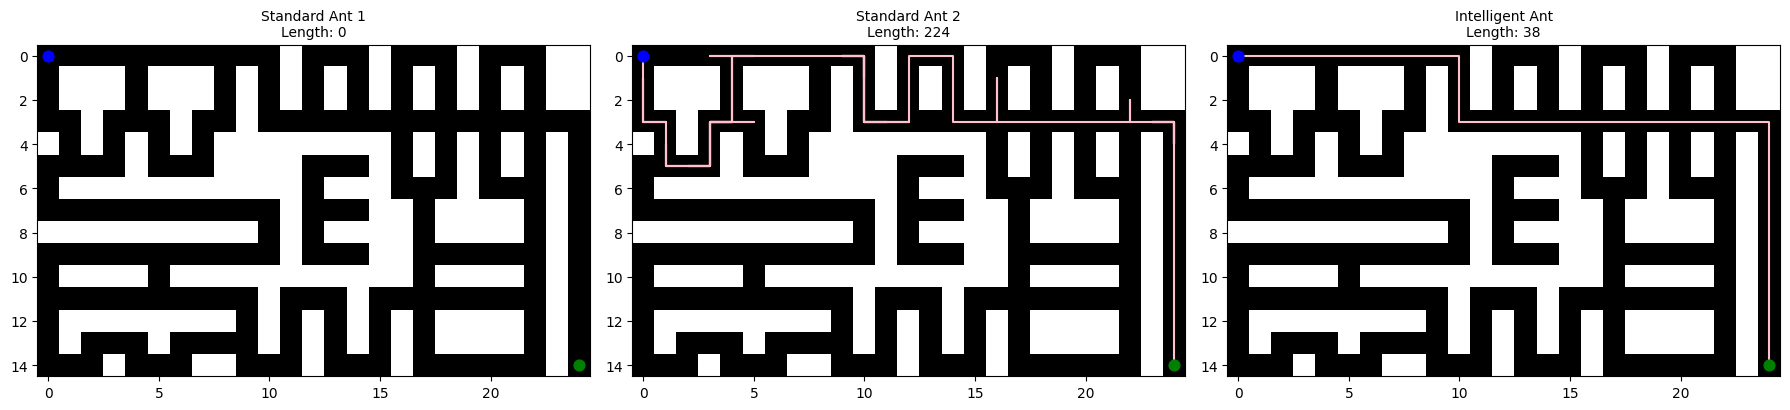

In [ ]:
# Running on the standard ants
m1, r1, s1 = run_aco('easy', 30, 100, 500, 0.3, 500, 20, intelligent=False)
m2, r2, s2 = run_aco('easy', 30, 100, 500, 0.3, 500, 20, intelligent=False)

# Running on intelligent ants
m3, r3, s3 = run_aco('easy', 30, 100, 500, 0.3, 500, 20, intelligent=True)

visualize_side_by_side([m1, m2, m3], [r1, r2, r3], [s1, s2, s3], ["Standard Ant 1", "Standard Ant 2" ,"Intelligent Ant"])


Running it for the medium maze, most runs in the standard ant implementation leads to no path being found almost every time. The Intelligent ants always find a path, thanks to the memory making it more efficient.

Ready reading maze file ./../data/medium_maze.txt
[Standard] Maze: medium | Time: 56.271s | Route size: 0
Ready reading maze file ./../data/medium_maze.txt
[Intelligent] Maze: medium | Time: 31.747s | Route size: 183


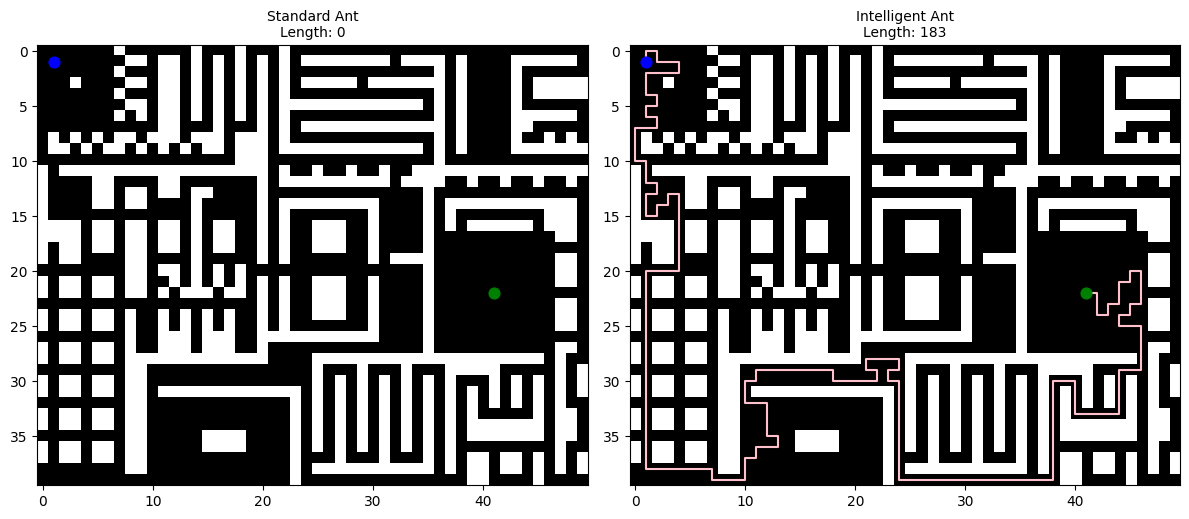

In [95]:
# Running on standard ants
m1, r1, s1 = run_aco('medium', 50, 300, 700, 0.3, 1000, 30, intelligent=False)

# Running on intelligent ants
m2, r2, s2 = run_aco('medium', 50, 300, 700, 0.3, 1000, 30, intelligent=True)

visualize_side_by_side([m1, m2], [r1, r2], [s1, s2], ["Standard Ant", "Intelligent Ant"])


### 2.5 Parameter Optimization

#### Question 16: Your task is to find a good set of parameters for each of the grading mazes. You may do so by varying the parameters and subsequently running your algorithm. Report your approach to tuning the parameters. Assist your text with graphs showing the relationships between the parameters and the speed of convergence. Present the impact of the hyper-parameter settings on the performance with visual aids.

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17: Using your answer to the previous question, how does the complexity and size of a maze influence the “optimal” value of each hyper-parameter?

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.6 The Final Route

#### Question 18: Run your code using your decent set of parameters on each of the grading mazes. Output your route as described in the Route Syntax section (you can verify the correctness by opening your route in the visualizer). See also “Deliverables” in Section 0.

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19: What are the differences (length, order of items, etc.) between the current path and the path found by your algorithmin Part 1? Which solution is better? Why?

In [0]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20: Genetic algorithms need a fitness function but there are many scenarios where you will not know the correct (underlying) fitness function. Discuss an example where this would be the case. How can it cause problems?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21: What about “survival functions”? Do we always want the strongest individual to survive? How can we mitigate these problems through themechanisms of selection?

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

|          Component          |    Eva    |  Iasonas  |    Guy    |   Miłosz  |
|-----------------------------|-----------|-----------|-----------|----------|
| Code (design)               |    20%    |    30%    |    25%    |    25%   |
| Code (implementation)       |    25%    |    25%    |    30%    |    20%   |
| Code (validation)           |    30%    |    20%    |    25%    |    25%   |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%   |
| Experiments (analysis)      |    20%    |    30%    |    25%    |    25%   |
| Experiments (visualisation) |    25%    |    25%    |    20%    |    30%   |
| Report (original draft)     |    30%    |    20%    |    25%    |    25%   |
| Report (reviewing & editing)|    25%    |    25%    |    25%    |    25%   |

### References

- Generative AI was used for help with the following:
    - **Markdown**: for example, making tables in Markdown or a diagram of the network
    - Assistance with debugging (e.g., noticing the need to change values into one-hot) and writing unit tests
    - Suggestions (mentioned in the code), and verification that the code is correct
    - Lastly, it was used for assistance for refintment of plots via `matplotlib`

# Time Estimates

| Question | Points | Type | Task | Est. Time |
|---|-----|------|------|-----------|
| **Part 1: GA** | **19** | **Write, Design, Code, Run** | **TSP analysis + GA implementation** | **2 hr** |
| 1 | 1 | Write | TSP definition + cite | 10 min |
| 2 | 3 | Write | Three differences from classic TSP | 10–20 min |
| 3 | 2 | Write | Why CI suits TSP | 10–20 min |
| 4 | 2 | Design | Chromosome encoding | 10–20 min |
| 5 | 1 | Write | Fitness function | 10 min |
| 6 | 1 | Write | Parent selection | 10 min |
| 7 | 3 | Write | Describe genetic operators | 10–20 min |
| 8 | 1 | Write | Local minima prevention | 10 min |
| 9 | 2 | Write | Elitism definition + application | 10–20 min |
| **10** | 3 | Code + Run + Write | Implement GA, execute, analyze | 1 hr |
| **Part 2: ACO** | **19** | **Write, Code, Experiments, Visuals, Run** | **ACO implementation + improvements + tuning** | **3–4 hr** |
| 11 | 1 | Write | ACO purpose and settings | 10 min |
| 12 | 1 | Write | Maze difficulty features | 10 min |
| 13 | 2 | Write | Pheromone deposition equation | 10–20 min |
| 14 | 2 | Write | Evaporation equation | 10–20 min |
| **15** | 5 | Code + Visuals | Base ACO + two improvements + visuals | 1–2 hr |
| **16** | 4 | Experiments + Visuals | Parameter tuning across 3 mazes | 1 hr |
| **17** | 2 | Write | Hyperparameter vs maze complexity | 20–30 min |
| 18 | 0 | Run | Generate route files | 10 min |
| 19 | 2 | Run + Write | Synthesis: compare ACO vs provided | 20 min |
| **Part 3: Open** | **8** | **Write, Pen & paper, Admin** | **Reflection + NSGA-II calculation** | **1-2 hr** |
| 20 | 2 | Write | Unknown fitness function example | 10–20 min |
| 21 | 2 | Write | Selection pressure + mitigation | 10–20 min |
| 22 | 4 | Pen & paper | NSGA-II Pareto fronts | 20–30 min |
| **Total** | **46** ||| **6–9 hr** |